#### Import all required libraries

In [216]:
import os
from dotenv import load_dotenv
import numpy as np
from sqlalchemy import create_engine
from pathlib import Path
import pandas as pd
from scipy.stats import kurtosis, zscore, f_oneway 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

In [74]:
%pip install python-dotenv sqlalchemy psycopg2-binary 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [75]:
env_path = Path("../.env")  
load_dotenv(dotenv_path=env_path)

# connect to the database
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST_LOCAL')}:{os.getenv('DB_PORT_LOCAL')}/{os.getenv('DB_NAME')}"
)

In [76]:
election_results= pd.read_sql_query('SELECT * FROM "silver"."election_results"',con=engine)

#### 1. Data Cleaning

In [77]:
election_results.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,MINORITY FRONT,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
1,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,NATIONAL DEMOCRATIC CONVENTION,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
2,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,PAN AFRICANIST CONGRESS OF AZANIA,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
3,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,SOUTH AFRICAN DEMOCRATIC CONGRESS,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
4,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,UNITED CHRISTIAN DEMOCRATIC PARTY,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551


From the first few rows of our dataset, we can see that it consists of election results data.

In [78]:
election_results.shape

(6262327, 11)

The dataset has 6 262 327 rows and 11 columns.

In [79]:
election_results.info()

<class 'pandas.DataFrame'>
RangeIndex: 6262327 entries, 0 to 6262326
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   province               str    
 1   municipality           str    
 2   voting_district        int64  
 3   party_name             str    
 4   registered_population  int64  
 5   voter_turnout_percent  float64
 6   party_votes            int64  
 7   year                   int64  
 8   election_type          str    
 9   ward                   float64
 10  total_votes            int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 525.6 MB


The datatypes of our columns look like what we expect.

In [80]:
election_results.describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,voting_district,registered_population,voter_turnout_percent,party_votes,year,ward,total_votes
count,6.26233e+06,6.26233e+06,6.2616e+06,6.26233e+06,6.26233e+06,6.19988e+06,6.26233e+06
mean,4.76875e+07,1197.92,735.114,369.192,2016.89,5.49576e+07,8656.38
std,2.81689e+07,1052.44,932.432,648.29,6.56137,2.65621e+07,15235.6
min,1.002e+07,0,0,0,2004,1.0101e+07,0
25%,2.24301e+07,440,56.37,0,2014,2.4404e+07,402
50%,4.35814e+07,857,70.48,2,2019,5.2802e+07,1280
75%,7.62201e+07,1694,1520.99,473,2024,7.98001e+07,9954
max,9.84303e+07,58802,85800,29401,2024,9.4706e+07,534934


- The ward column seems to have a lower count than the other columns, this may be because it have missing values.
- We will need to take note of the voter_turnout_percent as it has a maximum of 85 800 which is abnormal.

In [81]:
election_results.isnull().sum()

province                     0
municipality                29
voting_district              0
party_name                 127
registered_population        0
voter_turnout_percent      729
party_votes                  0
year                         0
election_type                0
ward                     62445
total_votes                  0
dtype: int64

There are missing values in the municipality, party_name, voter_turnout_percent and ward columns, we will need to figure out how to deal with them.

In [82]:
## deal with missing values

df= election_results
percent_missing = df.isnull().sum() * 100 / len(df)

print(percent_missing)

province                 0.000000
municipality             0.000463
voting_district          0.000000
party_name               0.002028
registered_population    0.000000
voter_turnout_percent    0.011641
party_votes              0.000000
year                     0.000000
election_type            0.000000
ward                     0.997153
total_votes              0.000000
dtype: float64


In [83]:
## we may be able to find the missing municipality from the voting districts
missing_munic=df[df["municipality"].isna()]
missing_munic

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
1513617,OUT OF COUNTRY,NaN,18888889,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513618,OUT OF COUNTRY,NaN,18888889,AFRICAN INDEPENDENT CONGRESS,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513619,OUT OF COUNTRY,NaN,18888889,AFRICAN NATIONAL CONGRESS,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513620,OUT OF COUNTRY,NaN,18888889,AFRICAN PEOPLE'S CONVENTION,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513621,OUT OF COUNTRY,NaN,18888889,AGANG SOUTH AFRICA,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513622,OUT OF COUNTRY,NaN,18888889,AL JAMA-AH,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513623,OUT OF COUNTRY,NaN,18888889,AZANIAN PEOPLE'S ORGANISATION,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513624,OUT OF COUNTRY,NaN,18888889,BUSHBUCKRIDGE RESIDENTS ASSOCIATION,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513625,OUT OF COUNTRY,NaN,18888889,DEMOCRATIC ALLIANCE,6789,7879.42,18446,2014,NATIONAL,NaN,534934
1513626,OUT OF COUNTRY,NaN,18888889,ECONOMIC FREEDOM FIGHTERS,6789,7879.42,18446,2014,NATIONAL,NaN,534934


We will drop the rows that have null values in the municipality column as they belong to "out of country votes".

In [84]:
df.dropna(subset= ["municipality"], inplace= True)

In [85]:
df.shape

(6262298, 11)

In [86]:
df= election_results
percent_missing = df.isnull().sum() * 100 / len(df)

print(percent_missing)

province                 0.000000
municipality             0.000000
voting_district          0.000000
party_name               0.002028
registered_population    0.000000
voter_turnout_percent    0.011641
party_votes              0.000000
year                     0.000000
election_type            0.000000
ward                     0.996695
total_votes              0.000000
dtype: float64


In [87]:
## check missing party name column
missing_party=df[df["party_name"].isna()]
missing_party.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
352619,Out of Country Voting,Out of Country Voting,18880308,NaN,0,NaN,0,2019,PROVINCIAL,NaN,0
352620,Out of Country Voting,Out of Country Voting,18880353,NaN,0,NaN,0,2019,PROVINCIAL,NaN,0
352621,Out of Country Voting,Out of Country Voting,18880487,NaN,0,NaN,0,2019,PROVINCIAL,NaN,0
352622,Out of Country Voting,Out of Country Voting,18880500,NaN,0,NaN,0,2019,PROVINCIAL,NaN,0
352623,Out of Country Voting,Out of Country Voting,18880533,NaN,0,NaN,0,2019,PROVINCIAL,NaN,0


We will be dropping the rows with missing party_name.

In [88]:
df.dropna(subset= ["party_name"], inplace= True)

In [89]:
df= election_results
percent_missing = df.isnull().sum() * 100 / len(df)

percent_missing.head()

province                 0.0
municipality             0.0
voting_district          0.0
party_name               0.0
registered_population    0.0
dtype: float64

In [90]:
## check missing voter_turnout_percent column
missing_party=df[df["voter_turnout_percent"].isna()]
missing_party.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
328971,Gauteng,TSH - Tshwane Metro,32951347,12,0,NaN,998,2019,PROVINCIAL,79900038.0,35928
328972,Gauteng,TSH - Tshwane Metro,32951347,12,0,NaN,998,2019,PROVINCIAL,79900038.0,35928
328973,Gauteng,TSH - Tshwane Metro,32951347,12,0,NaN,998,2019,PROVINCIAL,79900038.0,35928
328974,Gauteng,TSH - Tshwane Metro,32951347,12,0,NaN,998,2019,PROVINCIAL,79900038.0,35928
328975,Gauteng,TSH - Tshwane Metro,32951347,12,0,NaN,998,2019,PROVINCIAL,79900038.0,35928


We can see from the above that all the rows have 0 registered population, we will replace the missing values in voter_turnout_percent with 0 because if there were no registered population, then there was no turnout.

In [91]:
df["voter_turnout_percent"] = df["voter_turnout_percent"].fillna(0)

In [92]:
df= election_results
percent_missing = df.isnull().sum() * 100 / len(df)

percent_missing.head()

province                 0.0
municipality             0.0
voting_district          0.0
party_name               0.0
registered_population    0.0
dtype: float64

In [93]:
## check missing ward column
missing_party=df[df["ward"].isna()]
missing_party

voting_districts=missing_party["voting_district"]

In [94]:
df.dropna(subset= ["ward"], inplace= True)

In [95]:
df= election_results
percent_missing = df.isnull().sum() * 100 / len(df)

percent_missing.head()

province                 0.0
municipality             0.0
voting_district          0.0
party_name               0.0
registered_population    0.0
dtype: float64

In [96]:
df.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,MINORITY FRONT,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
1,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,NATIONAL DEMOCRATIC CONVENTION,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
2,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,PAN AFRICANIST CONGRESS OF AZANIA,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
3,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,SOUTH AFRICAN DEMOCRATIC CONGRESS,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
4,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,UNITED CHRISTIAN DEMOCRATIC PARTY,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551


#### 2. Checking for duplicates.

In [97]:
duplicateRows = df[df.duplicated()]

In [98]:
duplicateRows

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
328972,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
328973,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
328974,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
328975,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
328976,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
...,...,...,...,...,...,...,...,...,...,...,...
6252342,Mpumalanga,MP313 - Steve Tshwete,54600016,1164,0,0.0,0,2019,PROVINCIAL,83103016.0,0
6252600,Mpumalanga,MP313 - Steve Tshwete,54600016,1164,0,0.0,0,2019,PROVINCIAL,83103016.0,0
6252651,Mpumalanga,MP313 - Steve Tshwete,54600016,1164,0,0.0,0,2019,PROVINCIAL,83103016.0,0
6252702,Mpumalanga,MP313 - Steve Tshwete,54600016,1164,0,0.0,0,2019,PROVINCIAL,83103016.0,0


We will remove the duplicates in the dataset.

In [99]:
df.drop_duplicates(inplace=True)

#### 3. Checking for anomalies.

In [100]:
# Compute kurtosis for numeric columns 

kurtosis_values = df.select_dtypes(include=['float64', 
'int64']).apply(kurtosis) 
print("Kurtosis values:\n", kurtosis_values) 

Kurtosis values:
 voting_district           -1.155367
registered_population      4.097308
voter_turnout_percent    345.626122
party_votes                6.139593
year                      -0.816538
ward                      -1.300824
total_votes                9.071474
dtype: float64


The columns: "registered_population", "voter_turnout_percent", "party_votes" and "total_votes" have a kurtosis value that is greater than 3. We will have to investigate them further as they may contain errors or extreme values.

In [101]:
# investigate columns with high kurtosis values

## z-score for column with extreme kurtosis value

z_scores = zscore(df["voter_turnout_percent"])
filtered_data = df[(z_scores >= -2) & (z_scores <= 2)]

In [102]:
filtered_data.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,MINORITY FRONT,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
1,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,NATIONAL DEMOCRATIC CONVENTION,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
2,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,PAN AFRICANIST CONGRESS OF AZANIA,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
3,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,SOUTH AFRICAN DEMOCRATIC CONGRESS,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
4,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,UNITED CHRISTIAN DEMOCRATIC PARTY,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551


We have filtered the data to include only the rows with a z-score between -2 and 2 for the voter_turnout_percent.

In [103]:
filtered_data.shape

(6061969, 11)

In [104]:
# investigate columns with high kurtosis values 
## IQR for the rest of the columns

cols= ["registered_population", "party_votes", "total_votes"]

for col in cols:
    Q1= filtered_data[col].quantile(0.25)
    Q3= filtered_data[col].quantile(0.75)

    IQR=Q3-Q1
    print("IQR_" + col, IQR)

IQR_registered_population 1271.0
IQR_party_votes 442.0
IQR_total_votes 8771.0


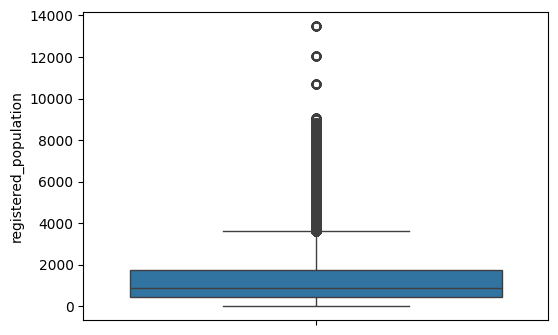

In [105]:
plt.figure(figsize= (6,4))
sns.boxplot(filtered_data["registered_population"])
plt.show()

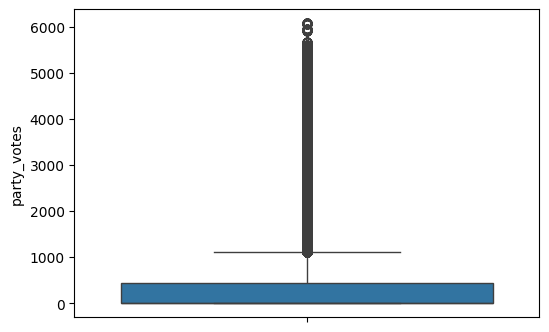

In [106]:
plt.figure(figsize= (6,4))
sns.boxplot(filtered_data["party_votes"])
plt.show()

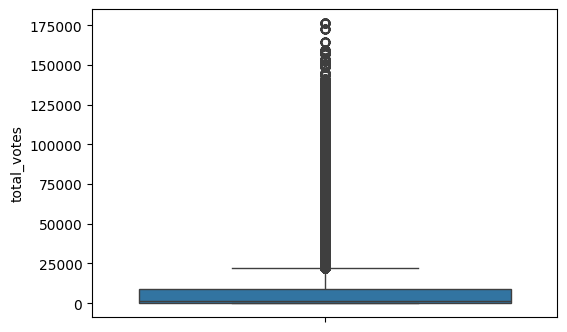

In [107]:
plt.figure(figsize= (6,4))
sns.boxplot(filtered_data["total_votes"])
plt.show()

The outliers in the 3 columns above are not of concern as it is expected for the values to range between extreme values.

In [108]:
df= filtered_data

df.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,MINORITY FRONT,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
1,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,NATIONAL DEMOCRATIC CONVENTION,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
2,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,PAN AFRICANIST CONGRESS OF AZANIA,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
3,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,SOUTH AFRICAN DEMOCRATIC CONGRESS,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551
4,KWAZULU-NATAL,KZN293 - NDWEDWE [NDWEDWE],43583913,UNITED CHRISTIAN DEMOCRATIC PARTY,661,1293.65,503,2009,PROVINCIAL,52903003.0,8551


In [109]:

count = df[df["voter_turnout_percent"] > 100].shape[0]


In [110]:
print(count)
print(df.shape[0])

2392376
6061969


In [111]:
extreme_percent=count * 100/df.shape[0]
print(extreme_percent)

39.46532883952392


Over 39% of the dataset has a voter turnout percentage that exceeds 100%. We will drop these rows as they are errors in the data.

In [112]:
df=df[df["voter_turnout_percent"]<=100]

In [113]:
df.shape

(3669593, 11)

### 4. Exploratory data analysis

<Axes: xlabel='registered_population', ylabel='Count'>

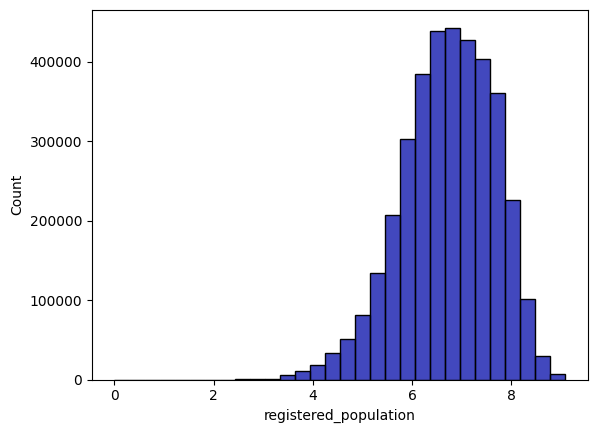

In [212]:
# visualise the spread of data
palette = ["#020AA9", "#007616", "#BBDF04",'#231F20', 
    '#F47920',  
    '#003DA5',  
    '#A8C8E8']
sns.histplot(df["registered_population"], bins=30, color=palette[0]) 

<Axes: xlabel='voter_turnout_percent', ylabel='Count'>

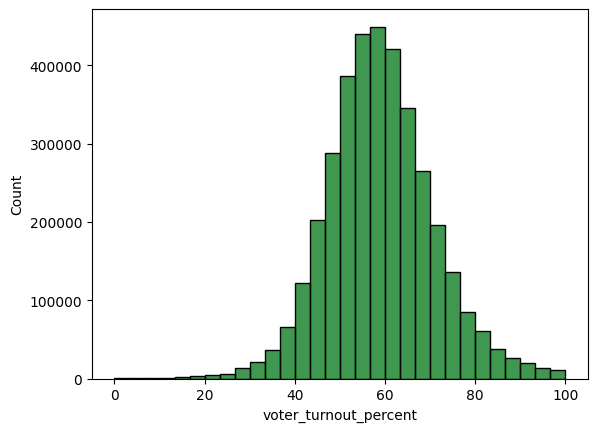

In [119]:
palette = ["#020AA9", "#007616", "#BBDF04"]
sns.histplot(df["voter_turnout_percent"], bins=30, color=palette[1]) 

In [123]:
numeric_check = df.apply(lambda col: pd.to_numeric(col, errors='coerce').notna().all())
print(numeric_check)


province                 False
municipality             False
voting_district           True
party_name               False
registered_population     True
voter_turnout_percent     True
party_votes               True
year                      True
election_type            False
ward                      True
total_votes               True
dtype: bool


<Axes: >

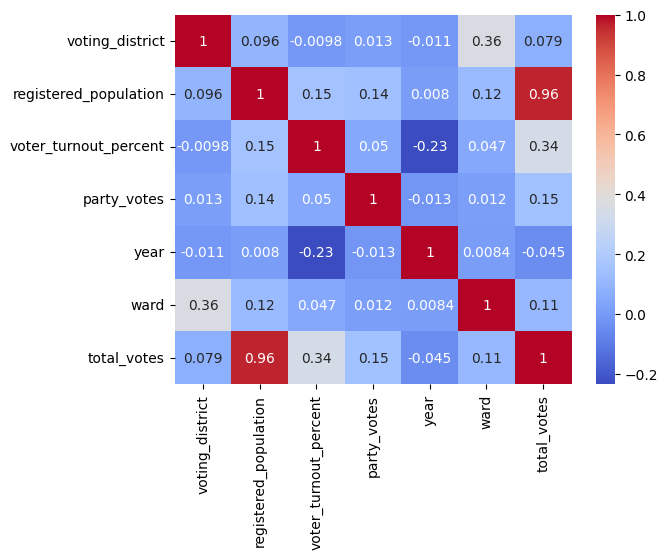

In [125]:
df.corr(numeric_only=True) 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

From the correlation matix above, we can see the pairs of attributes that have strong relationships.

<Axes: xlabel='registered_population', ylabel='total_votes'>

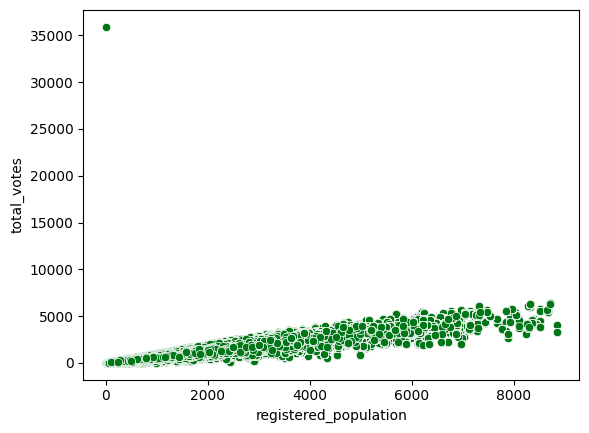

In [129]:
sns.scatterplot(x="registered_population", y= "total_votes", data=df, color= palette[1])

From the above scatterplot, we can see that the relationship between "total_votes" and "registered_population is positive and increasing. There is an outlier that indicates very high total votes yet from a population that had low registered people. We will need to investigate whether this is an error in the data.

In [137]:
result= df.loc[df["registered_population"]==0]
result

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
328971,Gauteng,TSH - Tshwane Metro,32951347,12,0,0.0,998,2019,PROVINCIAL,79900038.0,35928
343831,Gauteng,JHB - City of Johannesburg,32851278,2564,0,0.0,0,2019,PROVINCIAL,79800105.0,0
611176,Gauteng,GT481 - Mogale City,33250160,1347,0,0.0,0,2019,PROVINCIAL,74801038.0,0
613672,Western Cape,WC026 - Langeberg,97470041,815,0,0.0,0,2019,PROVINCIAL,10206006.0,0
613673,Gauteng,TSH - Tshwane Metro,86692652,1138,0,0.0,0,2019,PROVINCIAL,79900030.0,0
615406,Limpopo,LIM334 - Ba-Phalaborwa,76290969,106,0,0.0,0,2019,PROVINCIAL,93304011.0,0
616181,Mpumalanga,MP313 - Steve Tshwete,54600241,1011,0,0.0,0,2019,PROVINCIAL,83103024.0,0
618786,Mpumalanga,MP301 - Chief Albert Luthuli,54220395,477,0,0.0,0,2019,PROVINCIAL,83001005.0,0
926846,North West,NW372 - Madibeng,86680031,1996,0,0.0,0,2019,PROVINCIAL,63702030.0,0
947931,Western Cape,WC015 - Swartland,97710127,1635,0,0.0,0,2019,PROVINCIAL,10105011.0,0


We will be dropping the row that shows "total_votes">0 when there we no people that were registered to vote in the voting district.

In [141]:
df.drop(df[(df["total_votes"]==35928) & (df["registered_population"]==0)].index, inplace=True)
df.reset_index(drop=True, inplace=True)

<Axes: xlabel='registered_population', ylabel='total_votes'>

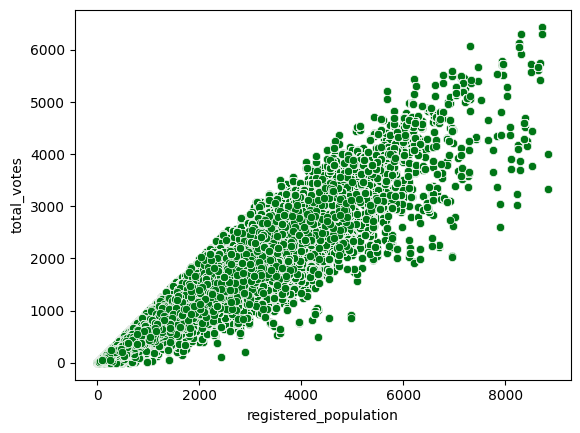

In [142]:
sns.scatterplot(x="registered_population", y= "total_votes", data=df, color= palette[1])

### 5. Feature Engineering

In [144]:
df.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,Mpumalanga,MP312 - Emalahleni,54650123,GOOD,5298,66.86,1,2024,PROVINCIAL,83102018.0,3542
1,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN INDEPENDENT CONGRESS,2996,63.12,0,2019,PROVINCIAL,79700080.0,1891
2,Mpumalanga,MP312 - Emalahleni,54650358,ABLE LEADERSHIP,1903,54.23,0,2024,PROVINCIAL,83102013.0,1032
3,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN NATIONAL CONGRESS,2996,63.12,1467,2019,PROVINCIAL,79700080.0,1891
4,Mpumalanga,MP312 - Emalahleni,54650381,GOOD,2145,33.85,0,2024,PROVINCIAL,83102022.0,726


<Axes: >

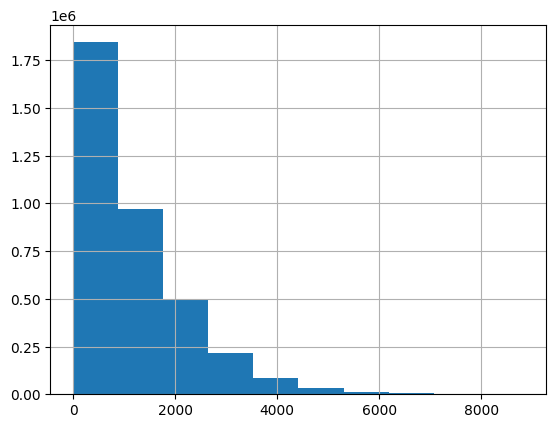

In [148]:
# inspecting distributions to make numeric features more model-friendly

df["registered_population"].hist()

The "registered_population" attribute is skewed to the right and we will apply a log1p transformation to it, which is a common method to reduce right skewness.

In [151]:
df["registered_population"]= np.log1p(df["registered_population"])

<Axes: >

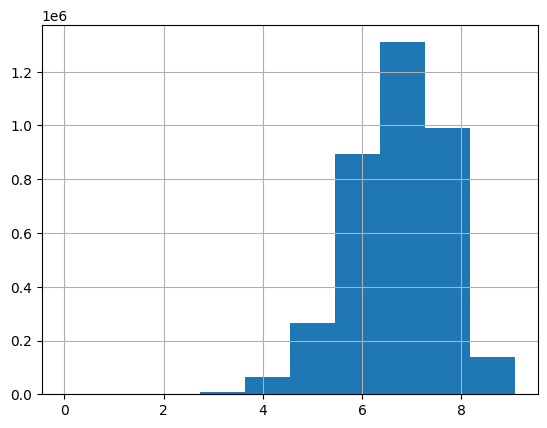

In [152]:
df["registered_population"].hist()

<Axes: >

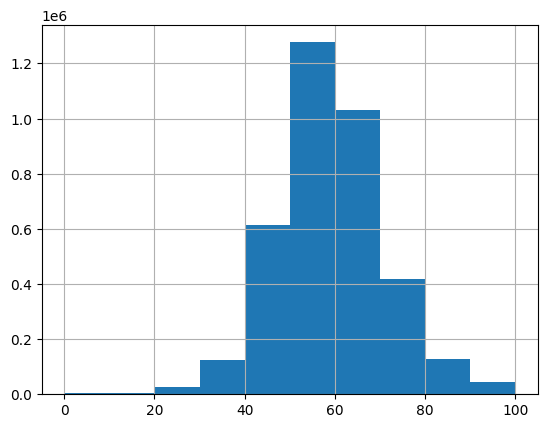

In [153]:
df["voter_turnout_percent"].hist()

<Axes: >

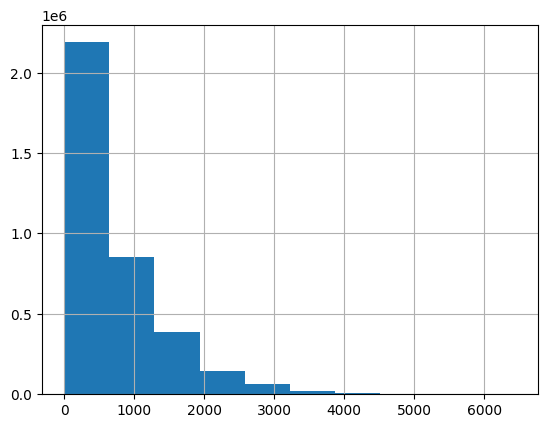

In [154]:
df["total_votes"].hist()

We will apply the log1p transformation for the above column as it is also skewed to the right.

In [155]:
df["total_votes"]= np.log1p(df["total_votes"])

<Axes: >

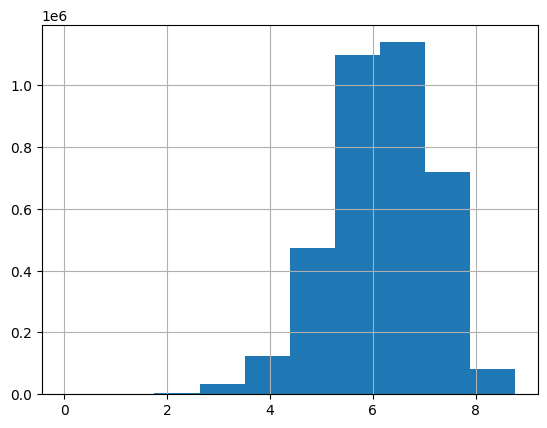

In [156]:
df["total_votes"].hist()

In [157]:
df.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes
0,Mpumalanga,MP312 - Emalahleni,54650123,GOOD,8.575273,66.86,1,2024,PROVINCIAL,83102018.0,8.172729
1,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN INDEPENDENT CONGRESS,8.005367,63.12,0,2019,PROVINCIAL,79700080.0,7.545390
2,Mpumalanga,MP312 - Emalahleni,54650358,ABLE LEADERSHIP,7.551712,54.23,0,2024,PROVINCIAL,83102013.0,6.940222
3,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN NATIONAL CONGRESS,8.005367,63.12,1467,2019,PROVINCIAL,79700080.0,7.545390
4,Mpumalanga,MP312 - Emalahleni,54650381,GOOD,7.671361,33.85,0,2024,PROVINCIAL,83102022.0,6.588926


There is no skewness in the "voter_turnout_percent" column.

In [158]:
# creating a new attribute that indicates the turnout gap

df["registered_turnout_gap"]= df["registered_population"]- df["total_votes"]



In [159]:
df.head()

,province,municipality,voting_district,party_name,registered_population,voter_turnout_percent,party_votes,year,election_type,ward,total_votes,registered_turnout_gap
0,Mpumalanga,MP312 - Emalahleni,54650123,GOOD,8.575273,66.86,1,2024,PROVINCIAL,83102018.0,8.172729,0.402544
1,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN INDEPENDENT CONGRESS,8.005367,63.12,0,2019,PROVINCIAL,79700080.0,7.545390,0.459977
2,Mpumalanga,MP312 - Emalahleni,54650358,ABLE LEADERSHIP,7.551712,54.23,0,2024,PROVINCIAL,83102013.0,6.940222,0.611490
3,Gauteng,EKU - Ekurhuleni,33090061,AFRICAN NATIONAL CONGRESS,8.005367,63.12,1467,2019,PROVINCIAL,79700080.0,7.545390,0.459977
4,Mpumalanga,MP312 - Emalahleni,54650381,GOOD,7.671361,33.85,0,2024,PROVINCIAL,83102022.0,6.588926,1.082434


In [161]:
# filter national and provincial elections

df = df[df['election_type'].isin(['NATIONAL', 'PROVINCIAL'])]

In [162]:
# split national and provincial elections to process 2 pipelines

df_national = df[df['election_type'] == 'NATIONAL']
df_provincial = df[df['election_type'] == 'PROVINCIAL']

In [220]:
assert df_provincial['election_type'].unique()[0] == 'PROVINCIAL', "❌ Provincial filter failed"
assert df_national['election_type'].unique()[0] == 'NATIONAL', "❌ National filter failed"
print("✅ Filtering passed")

✅ Filtering passed


In [163]:
# drop features that we do not need for modelling

cols_to_drop = ['ward', 'party_name', 'party_votes']
df_national.drop(columns=cols_to_drop, inplace=True)
df_provincial.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df_provincial_agg = df_provincial.groupby(
    ['province', 'municipality', 'voting_district', 'year'], as_index=False
).agg(
    voter_turnout_percent=('voter_turnout_percent', 'first'),
    registered_population=('registered_population', 'first'),
    total_votes=('total_votes', 'first'),
    registered_turnout_gap=('registered_turnout_gap', 'first'),
)


(45517, 8)
       province                             municipality  voting_district  \
0  EASTERN CAPE  EC157 - KING SABATA DALINDYEBO [UMTATA]         11590646   
1  EASTERN CAPE  EC157 - KING SABATA DALINDYEBO [UMTATA]         11591322   
2  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11810034   
3  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11810775   
4  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11811237   

   year  voter_turnout_percent  registered_population  total_votes  \
0  2014                   0.00               5.700444     0.000000   
1  2014                   0.00               5.356586     0.000000   
2  2014                  66.28               6.248043     5.837730   
3  2014                  44.89               5.996452     5.198497   
4  2014                  82.98               5.645447     5.459586   

   registered_turnout_gap  
0                5.700444  
1                5.356586  
2                0.41

In [168]:
prov_wide = df_provincial_agg.pivot_table(
    index=['province', 'municipality', 'voting_district'],
    columns='year',
    values=['voter_turnout_percent', 'registered_population', 'total_votes', 'registered_turnout_gap']
)

# Flatten multi-level columns
prov_wide.columns = ['_'.join(map(str, col)) for col in prov_wide.columns]
prov_wide = prov_wide.reset_index()

print(prov_wide.shape)
print(prov_wide.head())

(24484, 23)
       province                             municipality  voting_district  \
0  EASTERN CAPE  EC157 - KING SABATA DALINDYEBO [UMTATA]         11590646   
1  EASTERN CAPE  EC157 - KING SABATA DALINDYEBO [UMTATA]         11591322   
2  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11810034   
3  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11810775   
4  EASTERN CAPE          EC444 - NTABANKULU [NTABANKULU]         11811237   

   registered_population_2004  registered_population_2009  \
0                         NaN                         NaN   
1                         NaN                         NaN   
2                         NaN                         NaN   
3                         NaN                         NaN   
4                         NaN                         NaN   

   registered_population_2014  registered_population_2019  \
0                    5.700444                         NaN   
1                    5.356586       

In [169]:
turnout_cols = [f'voter_turnout_percent_{y}' for y in [2004, 2009, 2014, 2019, 2024]]
print(prov_wide[turnout_cols].isnull().sum())
print()
# What percentage of districts have all 5 years
print(prov_wide[turnout_cols].dropna().shape[0], "districts have all 5 elections")
print(prov_wide[turnout_cols].dropna(subset=['voter_turnout_percent_2024']).shape[0], "districts have 2024 data")

voter_turnout_percent_2004    24480
voter_turnout_percent_2009    24482
voter_turnout_percent_2014    24472
voter_turnout_percent_2019     2233
voter_turnout_percent_2024     1236
dtype: int64

0 districts have all 5 elections
23248 districts have 2024 data


In [170]:
prov_wide = prov_wide.dropna(subset=['voter_turnout_percent_2024'])
print(prov_wide.shape)

(23248, 23)


In [171]:
pairs = [(2004,2009), (2009,2014), (2014,2019), (2019,2024)]

for y1, y2 in pairs:
    col1 = f'voter_turnout_percent_{y1}'
    col2 = f'voter_turnout_percent_{y2}'
    if col1 in prov_wide.columns and col2 in prov_wide.columns:
        prov_wide[f'turnout_change_{y1}_{y2}'] = prov_wide[col2] - prov_wide[col1]

In [ ]:
years = [2004, 2009, 2014, 2019, 2024]

def turnout_trend(row):
    vals = [row.get(f'voter_turnout_percent_{y}', np.nan) for y in years]
    valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
    if len(valid) < 2:
        return np.nan
    x, y_vals = zip(*valid)
    return np.polyfit(x, y_vals, 1)[0]

prov_wide['turnout_trend_slope'] = prov_wide.apply(turnout_trend, axis=1)

In [173]:
muni_avg = prov_wide.groupby('municipality')['voter_turnout_percent_2024'].transform('mean')
prov_wide['district_vs_municipality_2024'] = prov_wide['voter_turnout_percent_2024'] - muni_avg

In [174]:
print(prov_wide.shape)
print(prov_wide[['turnout_change_2019_2024', 'turnout_trend_slope', 'district_vs_municipality_2024']].describe())

(23248, 29)
       turnout_change_2019_2024  turnout_trend_slope  \
count              21033.000000         21033.000000   
mean                  -5.445364            -5.445364   
std                    9.810737             9.810737   
min                  -67.520000           -67.520000   
25%                  -10.100000           -10.100000   
50%                   -4.720000            -4.720000   
75%                    0.120000             0.120000   
max                   72.900000            72.900000   

       district_vs_municipality_2024  
count                   2.324800e+04  
mean                    8.068792e-17  
std                     9.538271e+00  
min                    -5.922977e+01  
25%                    -5.336762e+00  
50%                    -1.106247e-01  
75%                     5.230239e+00  
max                     4.771602e+01  


In [175]:
prov_wide.drop(columns=['turnout_trend_slope'], inplace=True)

In [176]:
clustering_features = [
    'voter_turnout_percent_2024',
    'turnout_change_2019_2024',
    'registered_turnout_gap_2024',
    'district_vs_municipality_2024'
]

print(prov_wide[clustering_features].isnull().sum())

voter_turnout_percent_2024          0
turnout_change_2019_2024         2215
registered_turnout_gap_2024         0
district_vs_municipality_2024       0
dtype: int64


In [177]:
# fill missing values with median

median_change = prov_wide['turnout_change_2019_2024'].median()
print(f"Median turnout change: {median_change}")

prov_wide['turnout_change_2019_2024'] = prov_wide['turnout_change_2019_2024'].fillna(median_change)

print(prov_wide[clustering_features].isnull().sum())

Median turnout change: -4.720000000000006
voter_turnout_percent_2024       0
turnout_change_2019_2024         0
registered_turnout_gap_2024      0
district_vs_municipality_2024    0
dtype: int64


In [178]:
# add flag for districts that are new

prov_wide['is_new_district'] = prov_wide['turnout_change_2019_2024'].isna().astype(int)

In [ ]:
# now we will scale our features

clustering_features = [
    'voter_turnout_percent_2024',
    'turnout_change_2019_2024',
    'registered_turnout_gap_2024',
    'district_vs_municipality_2024'
]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(prov_wide[clustering_features])

print(df_scaled.shape)
print(df_scaled.mean(axis=0).round(4))  
print(df_scaled.std(axis=0).round(4))   

(23248, 4)
[0. 0. 0. 0.]
[1. 1. 1. 1.]


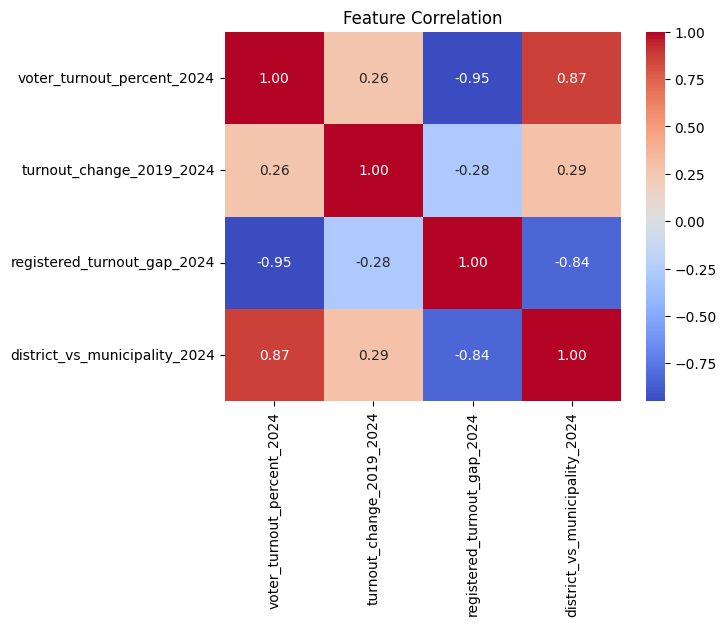

In [183]:
# check correlation again

corr = prov_wide[clustering_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [184]:
df_national_agg = df_national.groupby(
    ['province', 'municipality', 'voting_district', 'year'], as_index=False
).agg(
    voter_turnout_percent=('voter_turnout_percent', 'first'),
    registered_population=('registered_population', 'first'),
    total_votes=('total_votes', 'first'),
    registered_turnout_gap=('registered_turnout_gap', 'first'),
)


In [185]:
nat_wide = df_national_agg.pivot_table(
    index=['province', 'municipality', 'voting_district'],
    columns='year',
    values=['voter_turnout_percent', 'registered_population', 'total_votes', 'registered_turnout_gap']
)

nat_wide.columns = ['_'.join(map(str, col)) for col in nat_wide.columns]
nat_wide = nat_wide.reset_index()

print(nat_wide.shape)

(24436, 23)


In [186]:
turnout_cols = [f'voter_turnout_percent_{y}' for y in [2004, 2009, 2014, 2019, 2024]]
print(nat_wide[turnout_cols].isnull().sum())
print(nat_wide['voter_turnout_percent_2024'].notna().sum(), "districts have 2024 data")

voter_turnout_percent_2004    24435
voter_turnout_percent_2009    24435
voter_turnout_percent_2014    24428
voter_turnout_percent_2019     2341
voter_turnout_percent_2024     1204
dtype: int64
23232 districts have 2024 data


In [187]:
nat_wide = nat_wide.dropna(subset=['voter_turnout_percent_2024'])
print(nat_wide.shape)

(23232, 23)


In [221]:
# Unit test for aggregating the national and provicial datasets

assert df_provincial_agg.duplicated(subset=['voting_district', 'year']).sum() == 0, "❌ Duplicate district-year rows found in provincial"
assert df_national_agg.duplicated(subset=['voting_district', 'year']).sum() == 0, "❌ Duplicate district-year rows found in national"
print("✅ Aggregation passed")

✅ Aggregation passed


In [188]:
# Year over year turnout change
pairs = [(2004,2009), (2009,2014), (2014,2019), (2019,2024)]

for y1, y2 in pairs:
    col1 = f'voter_turnout_percent_{y1}'
    col2 = f'voter_turnout_percent_{y2}'
    if col1 in nat_wide.columns and col2 in nat_wide.columns:
        nat_wide[f'turnout_change_{y1}_{y2}'] = nat_wide[col2] - nat_wide[col1]

# District vs municipality average
muni_avg = nat_wide.groupby('municipality')['voter_turnout_percent_2024'].transform('mean')
nat_wide['district_vs_municipality_2024'] = nat_wide['voter_turnout_percent_2024'] - muni_avg

In [189]:
clustering_features = [
    'voter_turnout_percent_2024',
    'turnout_change_2019_2024',
    'registered_turnout_gap_2024',
    'district_vs_municipality_2024'
]

print(nat_wide[clustering_features].isnull().sum())

# Fill turnout change nulls with median and flag new districts
nat_wide['is_new_district'] = nat_wide['turnout_change_2019_2024'].isna().astype(int)
median_change = nat_wide['turnout_change_2019_2024'].median()
nat_wide['turnout_change_2019_2024'] = nat_wide['turnout_change_2019_2024'].fillna(median_change)

print(nat_wide[clustering_features].isnull().sum())

voter_turnout_percent_2024          0
turnout_change_2019_2024         2331
registered_turnout_gap_2024         0
district_vs_municipality_2024       0
dtype: int64
voter_turnout_percent_2024       0
turnout_change_2019_2024         0
registered_turnout_gap_2024      0
district_vs_municipality_2024    0
dtype: int64


In [190]:
scaler_nat = StandardScaler()
df_nat_scaled = scaler_nat.fit_transform(nat_wide[clustering_features])

print(df_nat_scaled.shape)
print(df_nat_scaled.mean(axis=0).round(4))
print(df_nat_scaled.std(axis=0).round(4))

(23232, 4)
[-0.  0. -0. -0.]
[1. 1. 1. 1.]


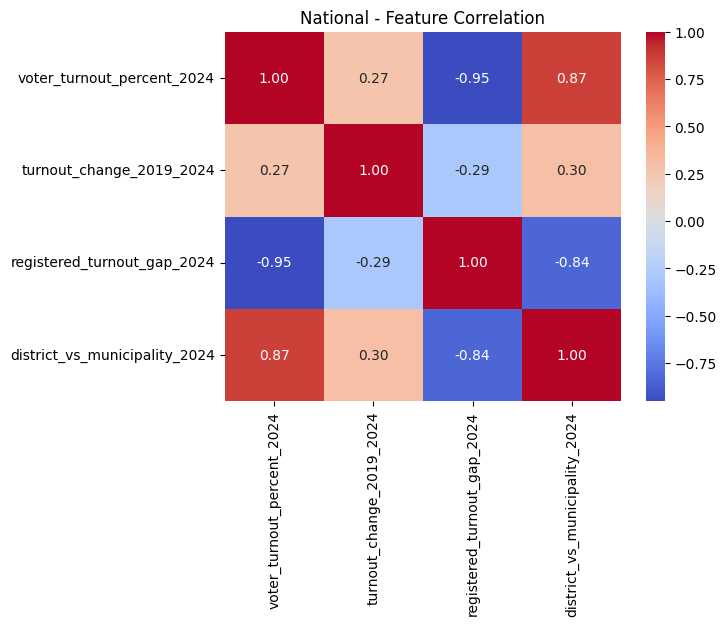

In [191]:
corr = nat_wide[clustering_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('National - Feature Correlation')
plt.show()

In [192]:
prov_wide.head()

,province,municipality,voting_district,registered_population_2004,registered_population_2009,registered_population_2014,registered_population_2019,registered_population_2024,registered_turnout_gap_2004,registered_turnout_gap_2009,...,voter_turnout_percent_2009,voter_turnout_percent_2014,voter_turnout_percent_2019,voter_turnout_percent_2024,turnout_change_2004_2009,turnout_change_2009_2014,turnout_change_2014_2019,turnout_change_2019_2024,district_vs_municipality_2024,is_new_district
5,Eastern Cape,BUF - Buffalo City,10590016,NaN,NaN,NaN,7.934513,7.872074,NaN,NaN,...,NaN,NaN,60.91,58.50,NaN,NaN,NaN,-2.41,-0.662818,0
6,Eastern Cape,BUF - Buffalo City,10590027,NaN,NaN,NaN,7.753194,7.806696,NaN,NaN,...,NaN,NaN,62.16,65.15,NaN,NaN,NaN,2.99,5.987182,0
7,Eastern Cape,BUF - Buffalo City,10590038,NaN,NaN,NaN,7.633854,7.571988,NaN,NaN,...,NaN,NaN,63.17,53.35,NaN,NaN,NaN,-9.82,-5.812818,0
8,Eastern Cape,BUF - Buffalo City,10590049,NaN,NaN,NaN,7.215240,7.090910,NaN,NaN,...,NaN,NaN,60.19,57.42,NaN,NaN,NaN,-2.77,-1.742818,0
9,Eastern Cape,BUF - Buffalo City,10590050,NaN,NaN,NaN,7.717351,7.737180,NaN,NaN,...,NaN,NaN,67.94,56.87,NaN,NaN,NaN,-11.07,-2.292818,0


### 6. Model selection and training

#### a. K-Means Clustering

#### Provincial elections data

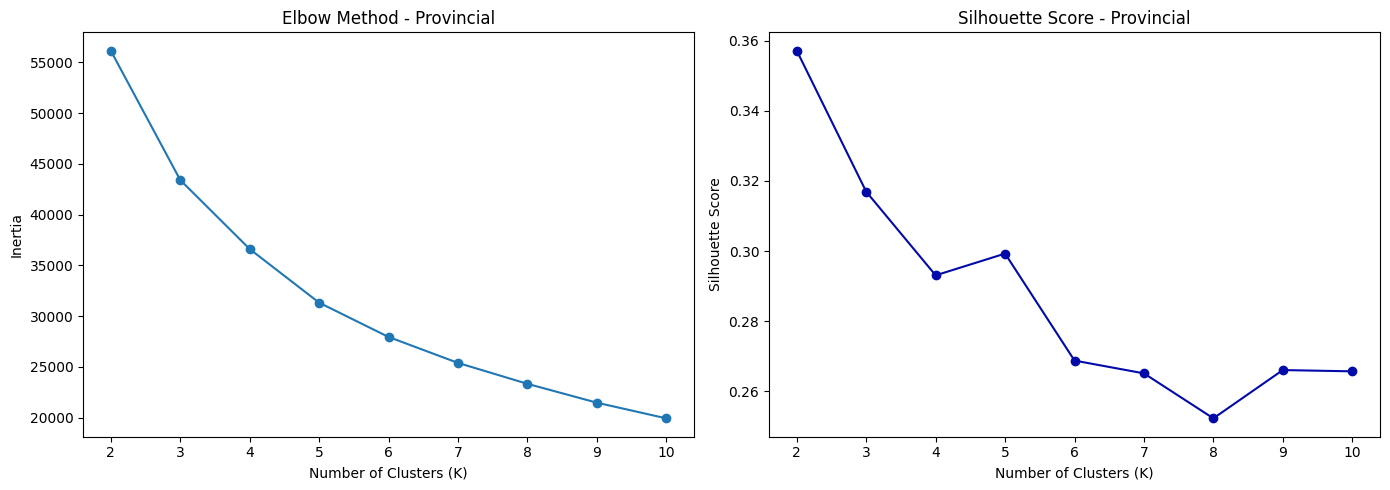

K=2 | Inertia: 56134.08 | Silhouette: 0.3571
K=3 | Inertia: 43406.16 | Silhouette: 0.3169
K=4 | Inertia: 36611.95 | Silhouette: 0.2931
K=5 | Inertia: 31330.50 | Silhouette: 0.2993
K=6 | Inertia: 27954.45 | Silhouette: 0.2688
K=7 | Inertia: 25400.51 | Silhouette: 0.2651
K=8 | Inertia: 23340.34 | Silhouette: 0.2523
K=9 | Inertia: 21484.32 | Silhouette: 0.2661
K=10 | Inertia: 19941.17 | Silhouette: 0.2657


In [196]:
# we will be doing unsupervised learning so we will start by running an elbow and silhouette plot

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - Provincial')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, marker='o', color=palette[0])
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - Provincial')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

# Print scores for reference
for k, inert, sil in zip(k_range, inertia, silhouette_scores):
    print(f"K={k} | Inertia: {inert:.2f} | Silhouette: {sil:.4f}")


We will go with 4 clusters.....

In [197]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
prov_wide['cluster'] = kmeans.fit_predict(df_scaled)

print(prov_wide['cluster'].value_counts())

cluster
3    10221
1     7963
0     3883
2     1181
Name: count, dtype: int64


In [198]:
prov_wide.groupby('cluster')[clustering_features].mean().round(2)

,voter_turnout_percent_2024,turnout_change_2019_2024,registered_turnout_gap_2024,district_vs_municipality_2024
cluster,,,,
0,72.24,-3.18,0.33,13.55
1,47.74,-7.83,0.74,-6.04
2,33.33,-18.86,1.13,-20.41
3,58.56,-2.74,0.54,1.92


In [199]:
cluster_labels = {
    0: 'Low Priority — High Turnout, Stable',
    1: 'High Priority — Low Turnout, Declining',
    2: 'Critical — Very Low Turnout, Severe Decline',
    3: 'Monitor — Average Turnout, Mild Decline'
}

prov_wide['cluster_label'] = prov_wide['cluster'].map(cluster_labels)
print(prov_wide['cluster_label'].value_counts())

cluster_label
Monitor — Average Turnout, Mild Decline        10221
High Priority — Low Turnout, Declining          7963
Low Priority — High Turnout, Stable             3883
Critical — Very Low Turnout, Severe Decline     1181
Name: count, dtype: int64


#### National elections data

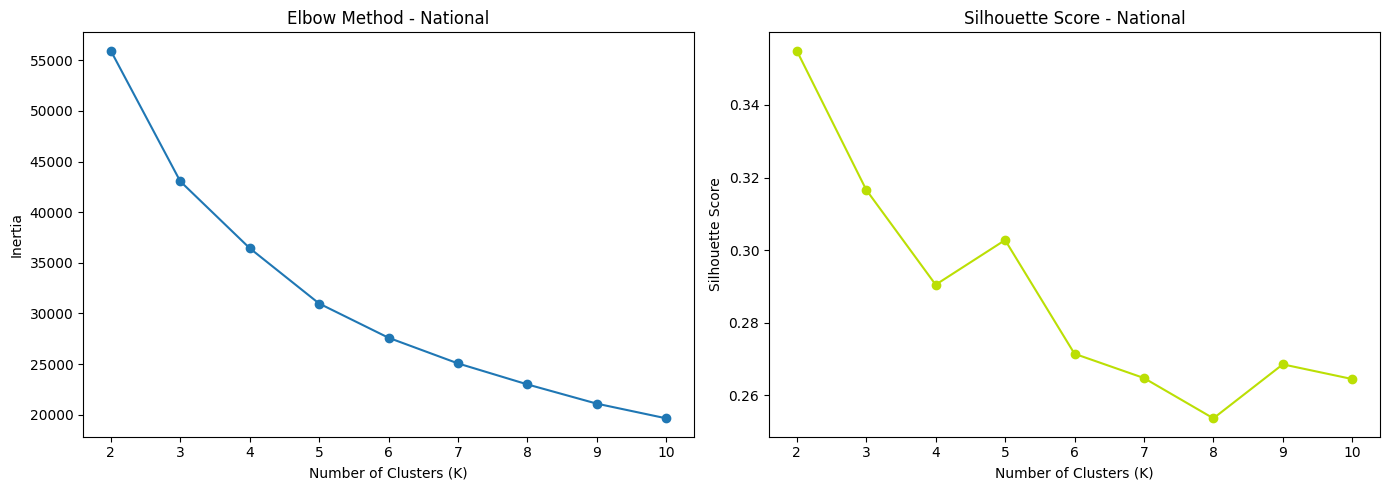

K=2 | Inertia: 55950.73 | Silhouette: 0.3549
K=3 | Inertia: 43054.96 | Silhouette: 0.3166
K=4 | Inertia: 36449.40 | Silhouette: 0.2905
K=5 | Inertia: 30981.67 | Silhouette: 0.3028
K=6 | Inertia: 27598.99 | Silhouette: 0.2715
K=7 | Inertia: 25065.67 | Silhouette: 0.2648
K=8 | Inertia: 22990.88 | Silhouette: 0.2537
K=9 | Inertia: 21089.56 | Silhouette: 0.2686
K=10 | Inertia: 19638.82 | Silhouette: 0.2645


In [203]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_nat_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_nat_scaled, labels))

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - National')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, marker='o', color=palette[2])
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score - National')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()

for k, inert, sil in zip(k_range, inertia, silhouette_scores):
    print(f"K={k} | Inertia: {inert:.2f} | Silhouette: {sil:.4f}")

We will also be going for 4 clusters in the national elections

In [205]:
kmeans_nat = KMeans(n_clusters=4, random_state=42, n_init=10)
nat_wide['cluster'] = kmeans_nat.fit_predict(df_nat_scaled)

nat_wide['cluster'].value_counts()
print()
nat_wide.groupby('cluster')[clustering_features].mean().round(2)

,voter_turnout_percent_2024,turnout_change_2019_2024,registered_turnout_gap_2024,district_vs_municipality_2024
cluster,,,,
0,73.20,-4.27,0.31,14.04
1,48.25,-9.27,0.73,-5.92
2,59.02,-3.71,0.53,1.95
3,34.60,-20.45,1.09,-19.62


In [206]:
cluster_labels_nat = {
    0: 'Low Priority — High Turnout, Stable',
    1: 'High Priority — Low Turnout, Declining',
    2: 'Monitor — Average Turnout, Mild Decline',
    3: 'Critical — Very Low Turnout, Severe Decline'
}

nat_wide['cluster_label'] = nat_wide['cluster'].map(cluster_labels_nat)
print(nat_wide['cluster_label'].value_counts())

cluster_label
Monitor — Average Turnout, Mild Decline        10092
High Priority — Low Turnout, Declining          8031
Low Priority — High Turnout, Stable             3806
Critical — Very Low Turnout, Severe Decline     1303
Name: count, dtype: int64


In [222]:
# Unit test for clustering the national and provincial datasets

assert prov_wide['cluster'].nunique() == 4, "❌ Provincial does not have 4 clusters"
assert nat_wide['cluster'].nunique() == 4, "❌ National does not have 4 clusters"
assert prov_wide['cluster'].value_counts().min() > 0, "❌ Empty cluster in provincial"
assert nat_wide['cluster'].value_counts().min() > 0, "❌ Empty cluster in national"
print("✅ Clustering passed")

✅ Clustering passed


In [207]:
# Add election type column for identification
prov_wide['election_type'] = 'PROVINCIAL'
nat_wide['election_type'] = 'NATIONAL'

# Stack both
final_df = pd.concat([prov_wide, nat_wide], ignore_index=True)

print(final_df.shape)
print(final_df[['election_type', 'cluster_label']].value_counts())

(46480, 32)
election_type  cluster_label                              
PROVINCIAL     Monitor — Average Turnout, Mild Decline        10221
NATIONAL       Monitor — Average Turnout, Mild Decline        10092
               High Priority — Low Turnout, Declining          8031
PROVINCIAL     High Priority — Low Turnout, Declining          7963
               Low Priority — High Turnout, Stable             3883
NATIONAL       Low Priority — High Turnout, Stable             3806
               Critical — Very Low Turnout, Severe Decline     1303
PROVINCIAL     Critical — Very Low Turnout, Severe Decline     1181
Name: count, dtype: int64


In [209]:

# Provincial
prov_sil = silhouette_score(df_scaled, prov_wide['cluster'])
prov_db = davies_bouldin_score(df_scaled, prov_wide['cluster'])

# National
nat_sil = silhouette_score(df_nat_scaled, nat_wide['cluster'])
nat_db = davies_bouldin_score(df_nat_scaled, nat_wide['cluster'])

print(f"Provincial — Silhouette: {prov_sil:.4f} | Davies-Bouldin: {prov_db:.4f}")
print(f"National   — Silhouette: {nat_sil:.4f} | Davies-Bouldin: {nat_db:.4f}")

Provincial — Silhouette: 0.2931 | Davies-Bouldin: 1.0819
National   — Silhouette: 0.2905 | Davies-Bouldin: 1.0962


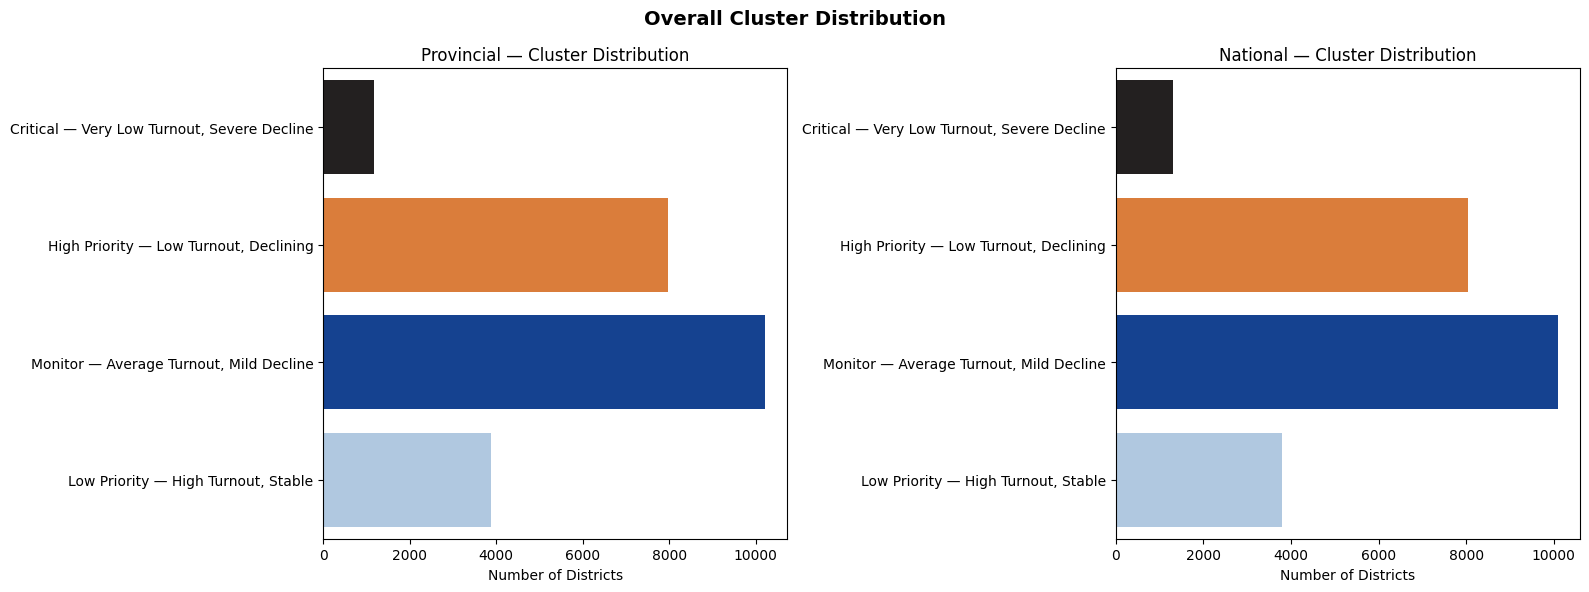

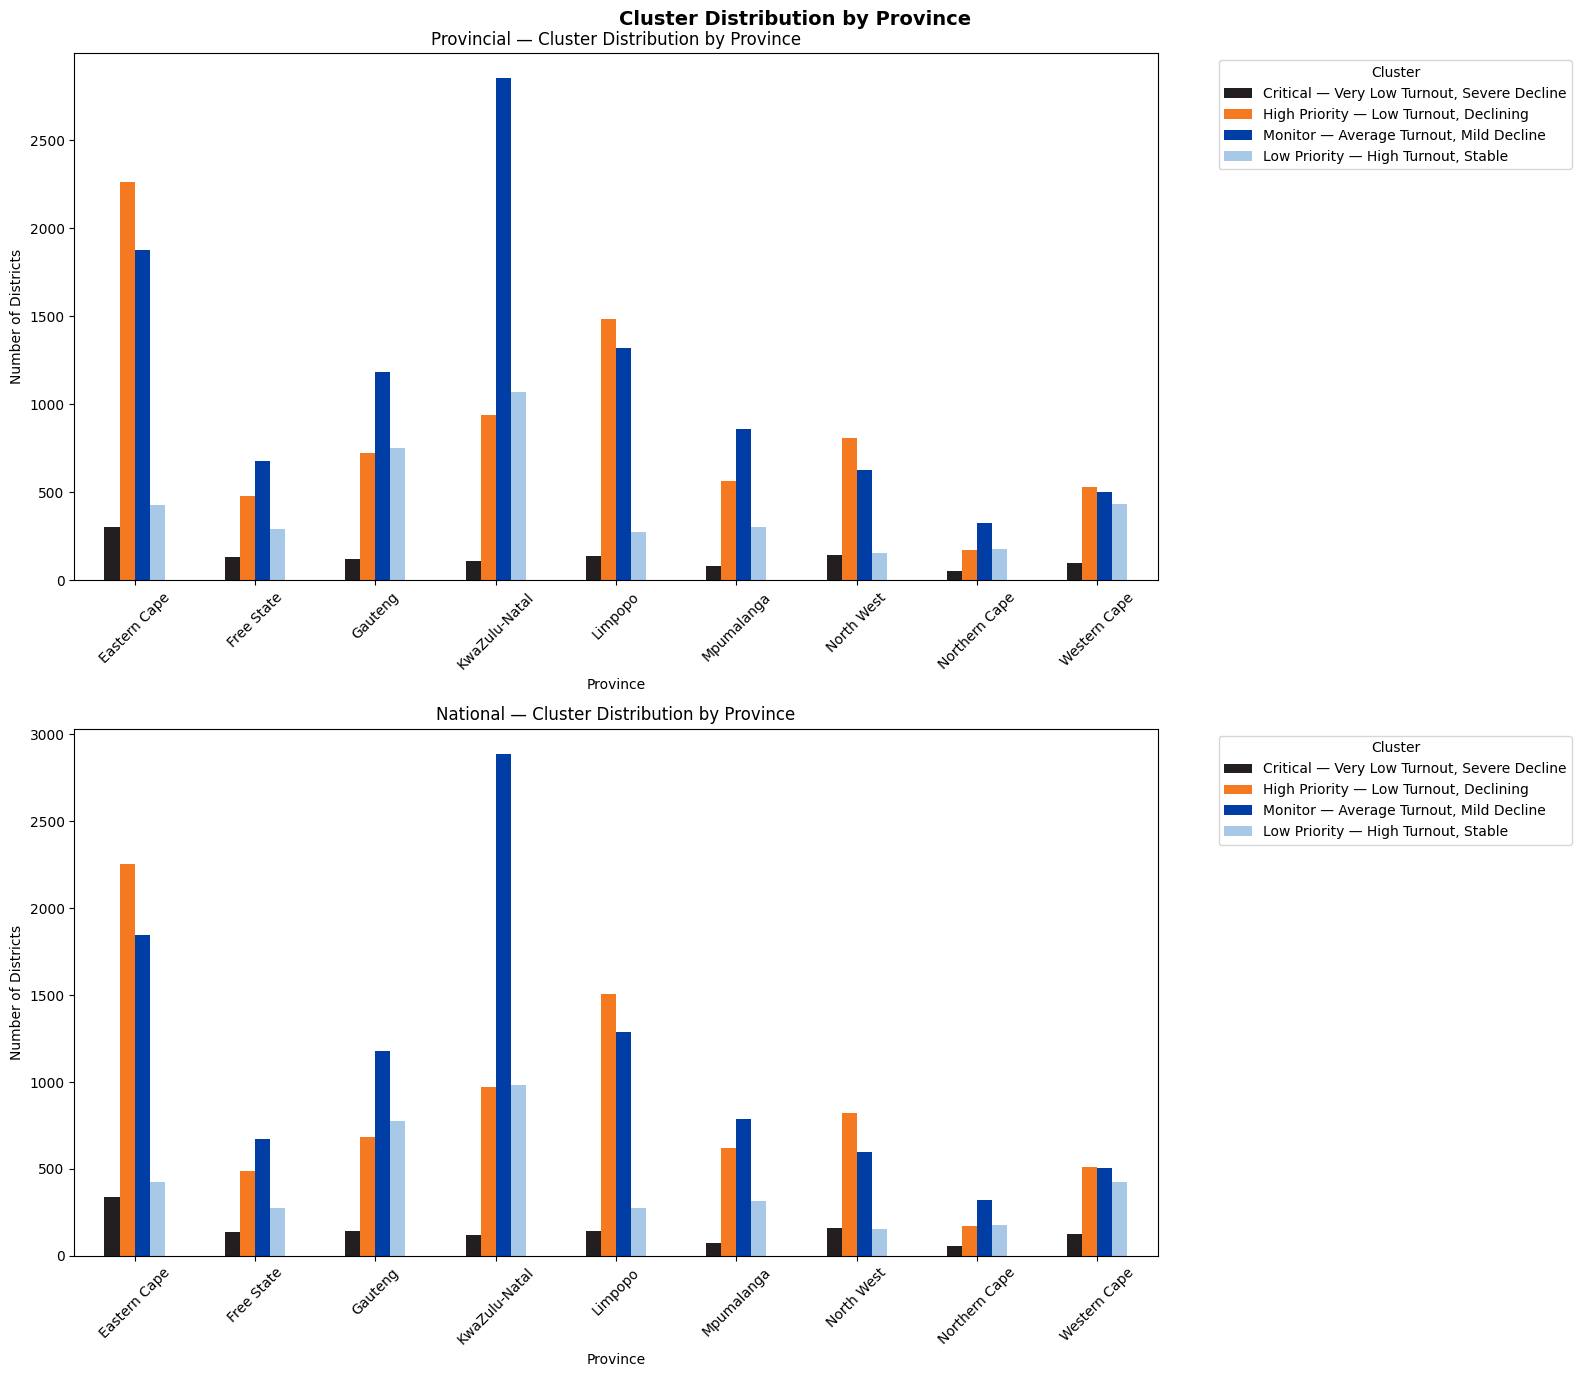

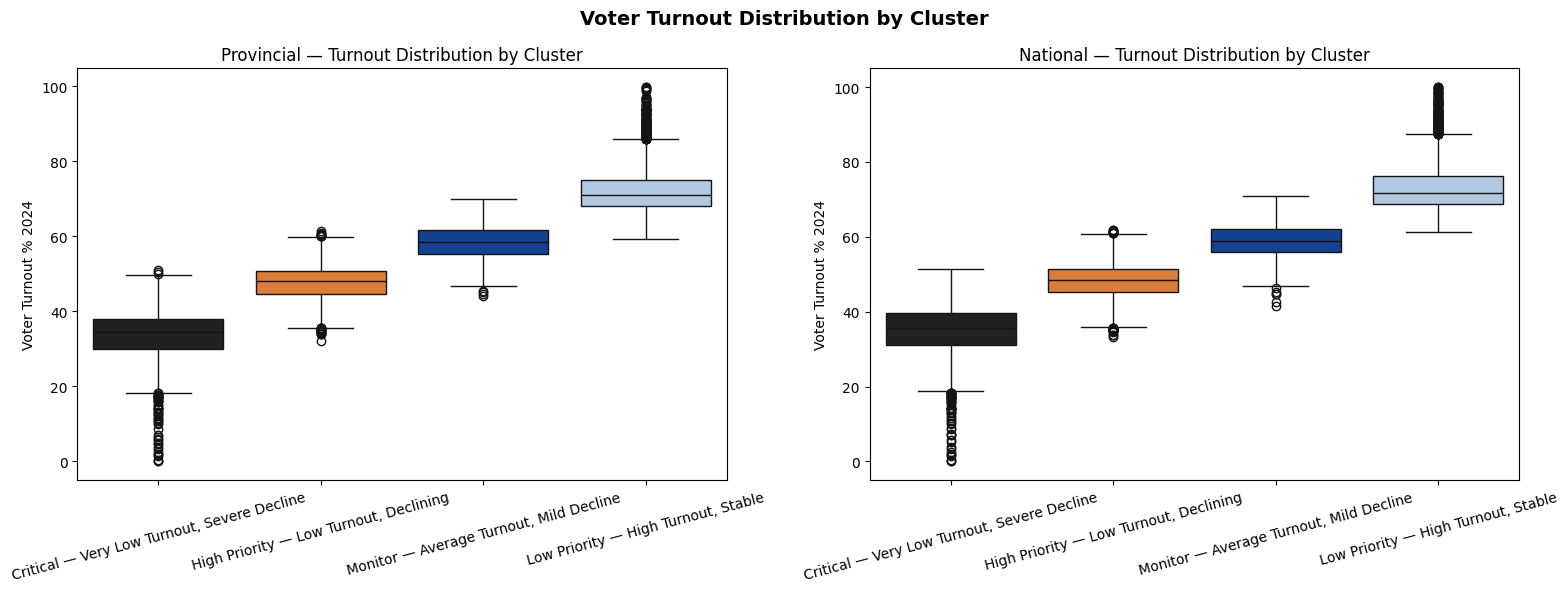

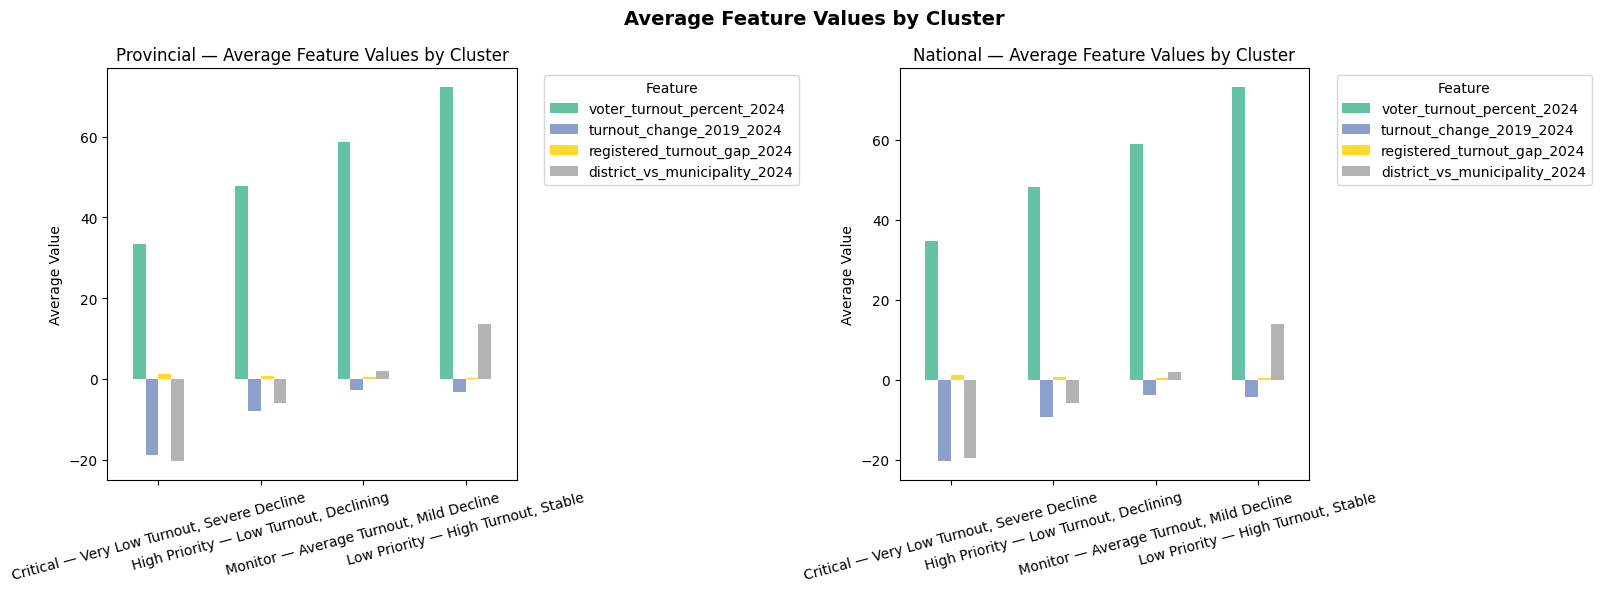

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

order = [
    'Critical — Very Low Turnout, Severe Decline',
    'High Priority — Low Turnout, Declining',
    'Monitor — Average Turnout, Mild Decline',
    'Low Priority — High Turnout, Stable'
]

colors = ['#231F20', '#F47920', '#003DA5', '#A8C8E8']
palette = dict(zip(order, colors))

# ── 1. Overall Cluster Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes,
                            [prov_wide, nat_wide],
                            ['Provincial', 'National']):
    sns.countplot(data=data, y='cluster_label', order=order,
                  hue='cluster_label', palette=palette, legend=False, ax=ax)
    ax.set_title(f'{title} — Cluster Distribution')
    ax.set_xlabel('Number of Districts')
    ax.set_ylabel('')

plt.suptitle('Overall Cluster Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Cluster Distribution by Province ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

for ax, data, title in zip(axes,
                            [prov_wide, nat_wide],
                            ['Provincial', 'National']):
    prov_counts = data.groupby(['province', 'cluster_label']).size().unstack(fill_value=0)
    for col in order:
        if col not in prov_counts.columns:
            prov_counts[col] = 0
    prov_counts[order].plot(kind='bar', ax=ax, color=colors)
    ax.set_title(f'{title} — Cluster Distribution by Province')
    ax.set_xlabel('Province')
    ax.set_ylabel('Number of Districts')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Cluster Distribution by Province', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Turnout Distribution by Cluster ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes,
                            [prov_wide, nat_wide],
                            ['Provincial', 'National']):
    sns.boxplot(data=data, x='cluster_label', y='voter_turnout_percent_2024',
                hue='cluster_label', order=order, palette=palette,
                legend=False, ax=ax)
    ax.set_title(f'{title} — Turnout Distribution by Cluster')
    ax.set_xlabel('')
    ax.set_ylabel('Voter Turnout % 2024')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Voter Turnout Distribution by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Average Feature Values by Cluster ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes,
                            [prov_wide, nat_wide],
                            ['Provincial', 'National']):
    cluster_means = data.groupby('cluster_label')[clustering_features].mean().reindex(order)
    cluster_means.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'{title} — Average Feature Values by Cluster')
    ax.set_xlabel('')
    ax.set_ylabel('Average Value')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Average Feature Values by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [215]:
# Confirm national labels are correct
print("National cluster labels:")
print(nat_wide['cluster_label'].value_counts())

print("\nFinal dataframe shape:")
print(final_df.shape)

print("\nCluster distribution by election type:")
print(final_df[['election_type', 'cluster_label']].value_counts())

National cluster labels:
cluster_label
Monitor — Average Turnout, Mild Decline        10092
High Priority — Low Turnout, Declining          8031
Low Priority — High Turnout, Stable             3806
Critical — Very Low Turnout, Severe Decline     1303
Name: count, dtype: int64

Final dataframe shape:
(46480, 32)

Cluster distribution by election type:
election_type  cluster_label                              
PROVINCIAL     Monitor — Average Turnout, Mild Decline        10221
NATIONAL       Monitor — Average Turnout, Mild Decline        10092
               High Priority — Low Turnout, Declining          8031
PROVINCIAL     High Priority — Low Turnout, Declining          7963
               Low Priority — High Turnout, Stable             3883
NATIONAL       Low Priority — High Turnout, Stable             3806
               Critical — Very Low Turnout, Severe Decline     1303
PROVINCIAL     Critical — Very Low Turnout, Severe Decline     1181
Name: count, dtype: int64


#### b. GMM 

In [217]:
# Provincial
gmm_prov = GaussianMixture(n_components=4, random_state=42)
prov_wide['cluster_gmm'] = gmm_prov.fit_predict(df_scaled)

prov_gmm_sil = silhouette_score(df_scaled, prov_wide['cluster_gmm'])
prov_gmm_db = davies_bouldin_score(df_scaled, prov_wide['cluster_gmm'])

# National
gmm_nat = GaussianMixture(n_components=4, random_state=42)
nat_wide['cluster_gmm'] = gmm_nat.fit_predict(df_nat_scaled)

nat_gmm_sil = silhouette_score(df_nat_scaled, nat_wide['cluster_gmm'])
nat_gmm_db = davies_bouldin_score(df_nat_scaled, nat_wide['cluster_gmm'])

# Comparison 
print("=" * 60)
print(f"{'Model':<20} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("=" * 60)
print(f"{'KMeans Provincial':<20} {'0.2931':>12} {'1.0819':>16}")
print(f"{'GMM Provincial':<20} {prov_gmm_sil:>12.4f} {prov_gmm_db:>16.4f}")
print("-" * 60)
print(f"{'KMeans National':<20} {'0.2905':>12} {'1.0962':>16}")
print(f"{'GMM National':<20} {nat_gmm_sil:>12.4f} {nat_gmm_db:>16.4f}")
print("=" * 60)

# Cluster counts
print("\nProvincial GMM cluster counts:")
print(prov_wide['cluster_gmm'].value_counts())

print("\nNational GMM cluster counts:")
print(nat_wide['cluster_gmm'].value_counts())

Model                  Silhouette   Davies-Bouldin
KMeans Provincial          0.2931           1.0819
GMM Provincial             0.2315           1.2652
------------------------------------------------------------
KMeans National            0.2905           1.0962
GMM National               0.2399           1.2331

Provincial GMM cluster counts:
cluster_gmm
2    8598
1    8408
3    4363
0    1879
Name: count, dtype: int64

National GMM cluster counts:
cluster_gmm
2    9407
1    7922
0    4418
3    1485
Name: count, dtype: int64


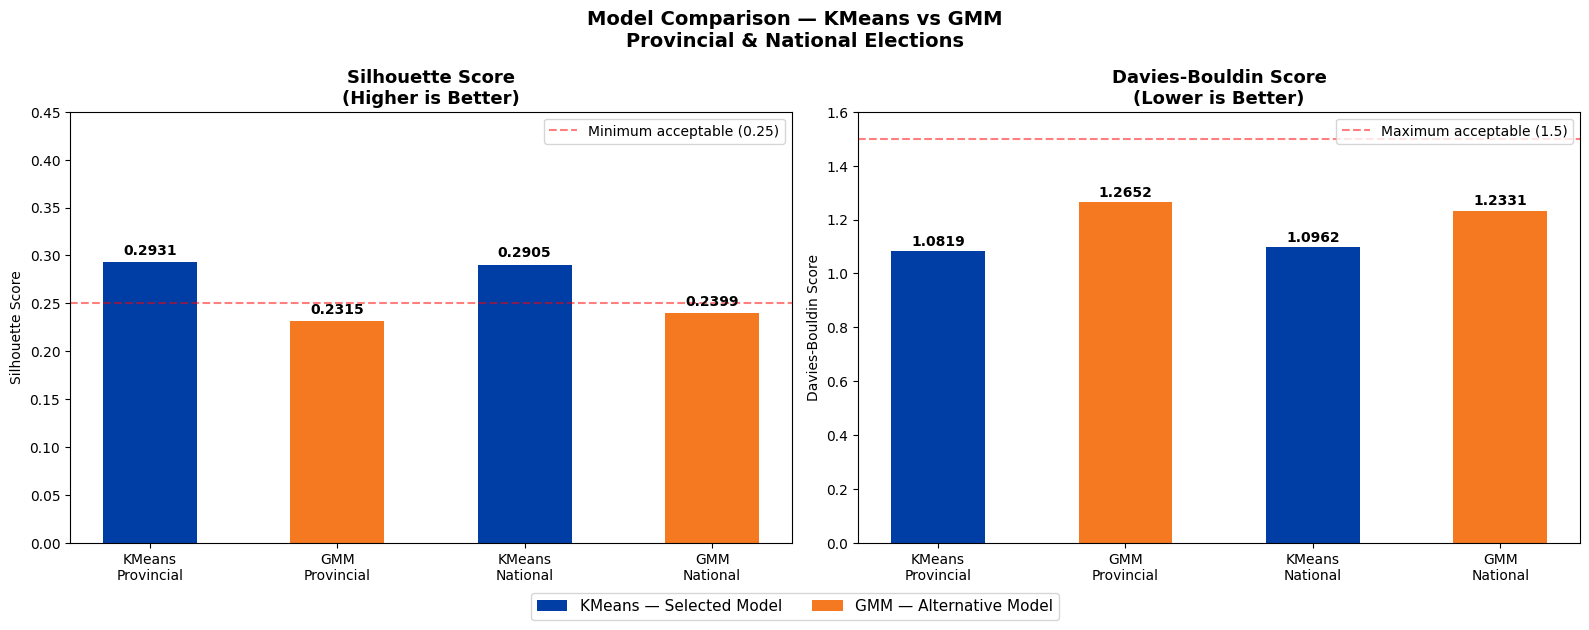

In [218]:
# Data
models = ['KMeans\nProvincial', 'GMM\nProvincial', 'KMeans\nNational', 'GMM\nNational']
silhouette = [0.2931, 0.2315, 0.2905, 0.2399]
davies_bouldin = [1.0819, 1.2652, 1.0962, 1.2331]

x = np.arange(len(models))
width = 0.35

iec_blue = '#003DA5'
iec_orange = '#F47920'

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Silhouette — higher is better
bars1 = axes[0].bar(x, silhouette, width=0.5, color=[iec_blue, iec_orange, iec_blue, iec_orange])
axes[0].set_title('Silhouette Score\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, 0.45)
axes[0].axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Minimum acceptable (0.25)')
axes[0].legend()

# Add value labels on bars
for bar, val in zip(bars1, silhouette):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin — lower is better
bars2 = axes[1].bar(x, davies_bouldin, width=0.5, color=[iec_blue, iec_orange, iec_blue, iec_orange])
axes[1].set_title('Davies-Bouldin Score\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_ylim(0, 1.6)
axes[1].axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='Maximum acceptable (1.5)')
axes[1].legend()

# Add value labels on bars
for bar, val in zip(bars2, davies_bouldin):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Legend 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=iec_blue, label='KMeans — Selected Model'),
    Patch(facecolor=iec_orange, label='GMM — Alternative Model')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Model Comparison — KMeans vs GMM\nProvincial & National Elections',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [219]:
print("Selected Model: KMeans (K=4)")
print("Reason: Higher silhouette and lower Davies-Bouldin scores")
print("across both Provincial and National election datasets")
print("compared to Gaussian Mixture Model alternative.")

Selected Model: KMeans (K=4)
Reason: Higher silhouette and lower Davies-Bouldin scores
across both Provincial and National election datasets
compared to Gaussian Mixture Model alternative.
